# **DSC530 – Data Exploration and Analysis**

## **Timothy Hollis**  
## **Week 7 & 8 Coding Assignment**  
## **February 15, 2026**

<hr style='height:3px; background-color:#333; border:none; margin:30px 0;'>

## **Assignment Overview**
This notebook contains the Chapter 5 and Chapter 6 exercises from *Hands-On Data Analysis with Pandas* (2nd Edition). The following datasets are used throughout the assignment:

- Earthquake events (USGS)  
- Facebook Stock Prices (2018)

<hr style='height:2px; background-color:#999; border:none; margin:30px 0;'>

## **Initial Setup**

The following code cell loads the required libraries, applies global display and plotting settings, and imports the two primary datasets used in this assignment.

In [8]:
# Import libraries
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Display formatting options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

# Base path for data files
BASE = Path('.')

# Load datasets
fb = pd.read_csv(BASE / 'fb_stock_prices_2018.csv', parse_dates=['date'])
earthquakes = pd.read_csv(BASE / 'earthquakes (ch5).csv')

# Preview first row of each dataset
display(fb.head(1))
display(earthquakes.head(1))

,date,open,high,low,close,volume
0,2018-01-02,177.68,181.58,177.55,181.42,18151903


,mag,magType,time,place,tsunami,parsed_place
0,1.35,ml,1539475168010,"9km NE of Aguanga, CA",0,California


<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

## **Chapter 5 — Exercise 1**  
### **Rolling 20‑Day Minimum of Facebook Closing Price**

Task: Plot the rolling 20‑day minimum of the Facebook closing price using pandas.

**Steps to complete:**

1. Select the `close` column from the Facebook dataset.  
2. Compute the 20‑day rolling minimum using `rolling()` and `min()`.  
3. Plot the rolling minimum as a line chart.  
4. Add a title, axis labels, and formatting for readability.

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

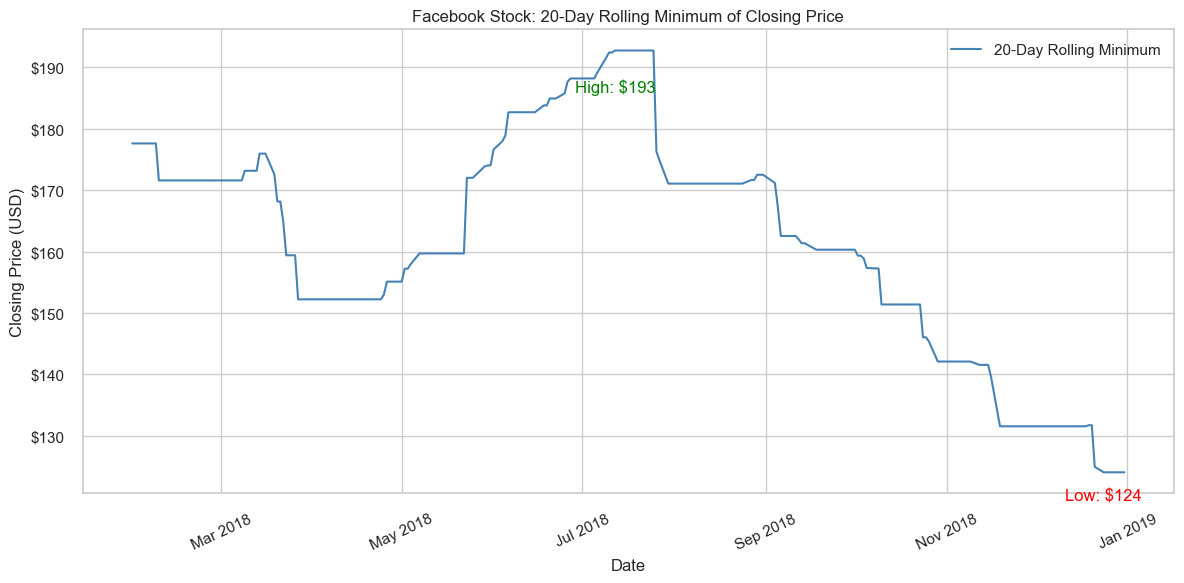

In [9]:
# 1. Select the closing price column
close_prices = fb['close']

# 2. Compute the 20-day rolling minimum
rolling_min_20 = close_prices.rolling(window=20).min()

# 3. Plot the rolling minimum
plt.figure(figsize=(12, 6))
plt.plot(
    fb['date'],
    rolling_min_20,
    label='20-Day Rolling Minimum',
    color='steelblue'
)

# 4. Format the x-axis dates
plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y')
)
plt.xticks(rotation=25)

# 5. Format y-axis tick labels as currency


def currency(x, pos):
    return f'${x:,.0f}'


plt.gca().yaxis.set_major_formatter(FuncFormatter(currency))

# Identify key points (min and max of the rolling minimum series)
min_value = rolling_min_20.min()
min_date = fb['date'].iloc[rolling_min_20.idxmin()]

max_value = rolling_min_20.max()
max_date = fb['date'].iloc[rolling_min_20.idxmax()]

# Annotate lowest point
plt.annotate(
    f'Low: ${min_value:,.0f}',
    xy=(min_date, min_value),
    xytext=(0, -20),
    textcoords='offset points',
    ha='center',
    color='red'
)

# Annotate highest point
plt.annotate(
    f'High: ${max_value:,.0f}',
    xy=(max_date, max_value),
    xytext=(0, -30),
    textcoords='offset points',
    ha='center',
    color='green'
)

# 6. Add title and axis labels
plt.title('Facebook Stock: 20-Day Rolling Minimum of Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

In this exercise, I computed the 20‑day rolling minimum of Facebook’s 2018 closing prices. Using Pandas’ `rolling()` and `min()` methods, I created a smoothed series that captures the lowest closing value within each 20‑day window. I then visualized the results with Matplotlib, applying month‑year date formatting, angled tick labels, and currency‑formatted y‑axis values for readability.

To improve interpretability, I annotated the lowest and highest values of the rolling‑minimum series directly on the plot, making it easy to identify key points in the trend.

## **Chapter 5 — Exercise 2**  
### **Distribution of Daily Change in Facebook Stock Price**

**Task:**  
Create a histogram and KDE of the change from open to close in the price of Facebook stock.

The daily change is calculated as:

$$
\text{Change} = \text{Close} - \text{Open}
$$

**Steps to complete:**

1. Compute the daily change.
2. Create histogram + KDE + zero line.
3. Format axes and add title/labels for the distribution plot.
4. Create the boxplot.
5. Format axes and add title/labels for the boxplot.

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

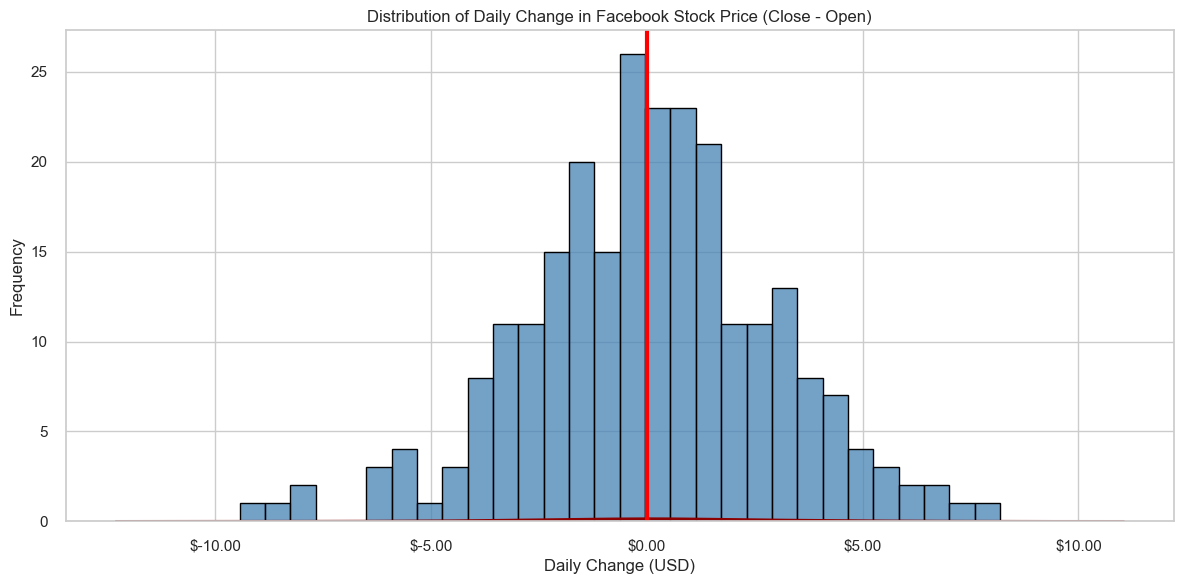

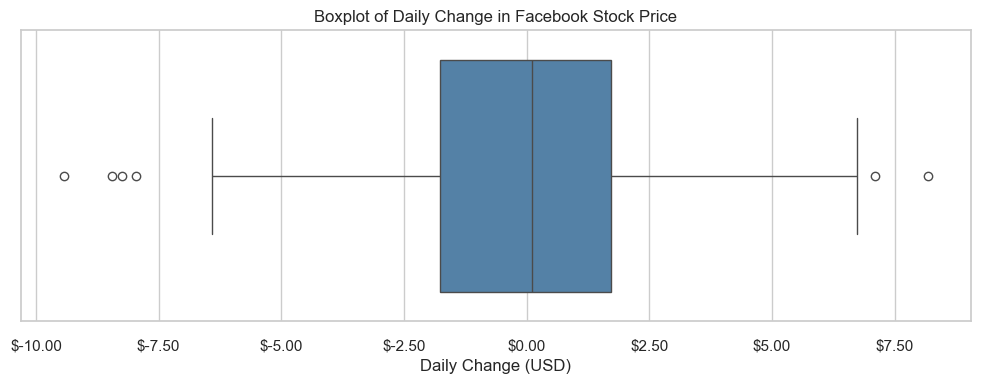

In [10]:
# 1. Compute the daily change from open to close
daily_change = fb['close'] - fb['open']

# 2. Create a histogram of the daily change values with KDE and a
# zero-change line
plt.figure(figsize=(12, 6))
sns.histplot(
    daily_change,
    bins=30,
    color='steelblue',
    edgecolor='black'
)
sns.kdeplot(
    daily_change,
    color='darkred',
    linewidth=2
)
plt.axvline(0, color='red', linestyle='-', linewidth=3)

# 3. Format axes and add title/labels for the distribution plot


def currency(x, pos):
    return f'${x:,.2f}'


plt.gca().xaxis.set_major_formatter(FuncFormatter(currency))
plt.title('Distribution of Daily Change in Facebook Stock Price (Close - Open)')
plt.xlabel('Daily Change (USD)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4. Create a boxplot of the daily change to highlight spread and outliers
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=daily_change,
    color='steelblue'
)

# 5. Format axes and add title/labels for the boxplot
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency))
plt.title('Boxplot of Daily Change in Facebook Stock Price')
plt.xlabel('Daily Change (USD)')

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

This exercise examined the distribution of daily price changes in Facebook’s 2018 stock data, calculated as the difference between the closing and opening prices for each trading day. The histogram and KDE curve provided a clear view of how these daily changes were distributed, revealing the overall shape, central tendency, and variability of the stock’s intraday movement. Adding a vertical reference line at zero helped distinguish positive from negative changes, making it easier to interpret how often the stock gained or lost value during the trading day.

To complement the distribution plot, a boxplot was created to highlight the spread, median, and presence of outliers in the daily change values. 


## **Chapter 5 — Exercise 3**  
### **Boxplots of Earthquake Magnitudes by magType in Indonesia**

**Task:**  
Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

**Steps to complete:**

1. Filter to Indonesia
2. Select `mag` and `magType` 
3. Create a bar chart showing the count of each magType
4. Create boxplots of magnitude values for each magType
5. Create a tectonic map showing why Indonesia experiences earthquakes, providing geological context for the statistical analysis

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

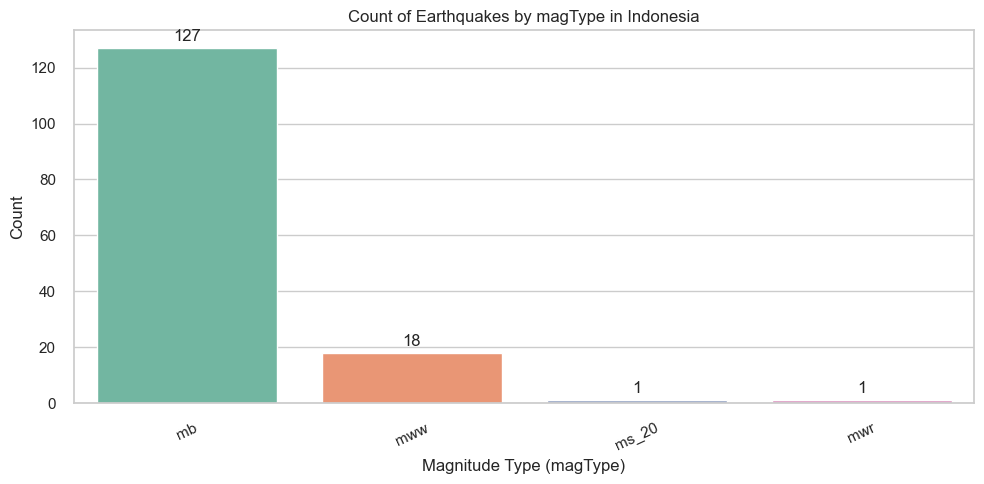

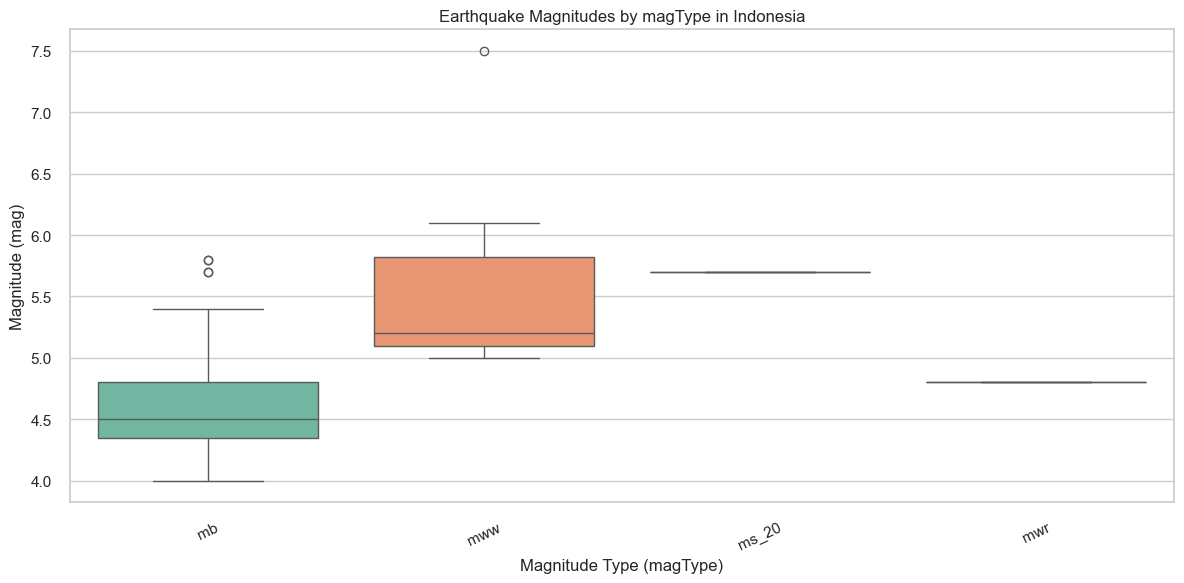

GEOLOGICAL CONTEXT ANALYSIS

Summary Statistics for Map Display:
• Total earthquakes analyzed: 147
• Average magnitude: 4.72
• Maximum magnitude: 7.50
• Magnitude types present: mb, mww, ms_20, mwr


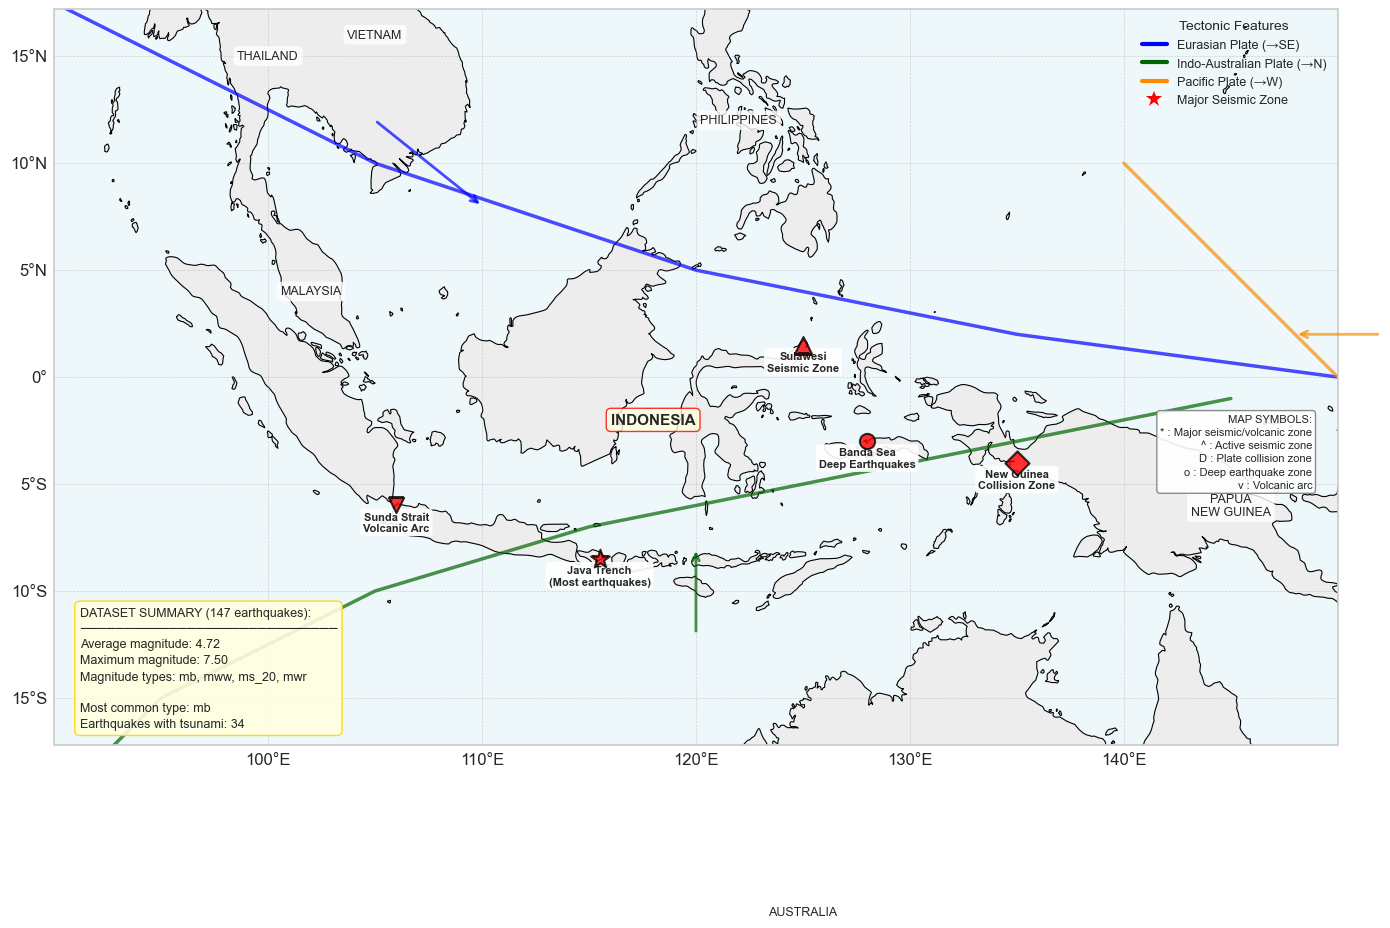

Cartopy Value

The tectonic map provides context for understanding:
1. Why Indonesia experiences diverse earthquake types
2. How different magnitude measurement methods (magType)
   correspond to different seismic characteristics
3. The relationship between plate tectonics and
   earthquake frequency/magnitude
4. I wanted to practice using cartopy, though intense,
   was worth the effort to get the practice


In [11]:
# 1. Filter to Indonesia
in_indonesia = earthquakes['parsed_place'].str.contains(
    'Indonesia', case=False, na=False)
indo_quakes = earthquakes[in_indonesia].copy()

# 2. Select the magnitude and magType columns
indo_quakes = indo_quakes[['mag', 'magType']].dropna()

# 3. Create a bar chart showing the count of each magType
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=indo_quakes,
    x='magType',
    hue='magType',
    palette='Set2',
    legend=False
)

# Add count labels above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Count of Earthquakes by magType in Indonesia')
plt.xlabel('Magnitude Type (magType)')
plt.ylabel('Count')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# 4. Create boxplots of magnitude values for each magType
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=indo_quakes,
    x='magType',
    y='mag',
    hue='magType',
    palette='Set2',
    legend=False
)

plt.title('Earthquake Magnitudes by magType in Indonesia')
plt.xlabel('Magnitude Type (magType)')
plt.ylabel('Magnitude (mag)')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# 5. Geological context: tectonic map showing why Indonesia experiences
# earthquakes
print("GEOLOGICAL CONTEXT ANALYSIS")

# Reattach place information for contextual mapping
indo_quakes_with_places = earthquakes.loc[indo_quakes.index].copy()

# Calculate summary statistics for display
total_quakes = len(indo_quakes)
avg_magnitude = indo_quakes['mag'].mean()
max_magnitude = indo_quakes['mag'].max()
mag_types_list = indo_quakes['magType'].unique()

print(f"\nSummary Statistics for Map Display:")
print(f"• Total earthquakes analyzed: {total_quakes}")
print(f"• Average magnitude: {avg_magnitude:.2f}")
print(f"• Maximum magnitude: {max_magnitude:.2f}")
print(f"• Magnitude types present: {', '.join(mag_types_list)}")

# Create the tectonic context visualization
fig = plt.figure(figsize=(14, 10))

# Base map using PlateCarree projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land, ocean, and coastlines
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.coastlines(linewidth=0.8, color='black')

# Set map extent to Indonesia region
ax.set_extent([90, 150, -15, 15])
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                  alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Label nearby countries
countries_to_label = {
    'INDONESIA': (118, -2),
    'MALAYSIA': (102, 4),
    'PHILIPPINES': (122, 12),
    'PAPUA\nNEW GUINEA': (145, -6),
    'AUSTRALIA': (125, -25),
    'THAILAND': (100, 15),
    'VIETNAM': (105, 16)
}

for country, (lon, lat) in countries_to_label.items():
    ax.text(
        lon,
        lat,
        country,
        transform=ccrs.PlateCarree(),
        fontsize=9 if country != 'INDONESIA' else 11,
        ha='center',
        va='center',
        fontweight='bold' if country == 'INDONESIA' else 'normal',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor='white' if country != 'INDONESIA' else 'lightyellow',
            alpha=0.8,
            edgecolor='red' if country == 'INDONESIA' else 'none'))

# Plot tectonic plate boundaries
eurasian_boundary = [(85, 20), (95, 15), (105, 10),
                     (120, 5), (135, 2), (150, 0)]
eurasian_lons, eurasian_lats = zip(*eurasian_boundary)
ax.plot(eurasian_lons, eurasian_lats, color='blue', linewidth=2.5,
        transform=ccrs.PlateCarree(), linestyle='-', alpha=0.7)

indo_australian_boundary = [(85, -25), (95, -15), (105, -10), (115, -7),
                            (125, -5), (135, -3), (145, -1)]
indo_lons, indo_lats = zip(*indo_australian_boundary)
ax.plot(indo_lons, indo_lats, color='darkgreen', linewidth=2.5,
        transform=ccrs.PlateCarree(), linestyle='-', alpha=0.7)

pacific_boundary = [(140, 10), (145, 5), (150, 0), (155, -5)]
pacific_lons, pacific_lats = zip(*pacific_boundary)
ax.plot(pacific_lons, pacific_lats, color='darkorange', linewidth=2.5,
        transform=ccrs.PlateCarree(), linestyle='-', alpha=0.7)

# Add plate motion arrows
ax.annotate('', xy=(110, 8), xytext=(105, 12),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2, alpha=0.7))
ax.annotate('', xy=(120, -8), xytext=(120, -12),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2, alpha=0.7))
ax.annotate(
    '', xy=(
        148, 2), xytext=(
            152, 2), arrowprops=dict(
                arrowstyle='->', color='darkorange', lw=2, alpha=0.7))

# Mark major seismic zones
seismic_zones = [
    (115.5, -8.5, 'Java Trench\n(Most earthquakes)', '*', 200),
    (125, 1.5, 'Sulawesi\nSeismic Zone', '^', 150),
    (135, -4, 'New Guinea\nCollision Zone', 'D', 150),
    (128, -3, 'Banda Sea\nDeep Earthquakes', 'o', 120),
    (106, -6, 'Sunda Strait\nVolcanic Arc', 'v', 120)
]

for lon, lat, label, marker, size in seismic_zones:
    ax.scatter(lon, lat, s=size, marker=marker,
               c='red', alpha=0.8, transform=ccrs.PlateCarree(),
               edgecolors='black', linewidth=1.5, zorder=10)
    ax.text(lon, lat - 1.2, label, transform=ccrs.PlateCarree(),
            fontsize=8, ha='center', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))

# Add dataset summary box
data_summary = (
    f"DATASET SUMMARY ({total_quakes} earthquakes):\n"
    f"─────────────────────────────\n"
    f"Average magnitude: {avg_magnitude:.2f}\n"
    f"Maximum magnitude: {max_magnitude:.2f}\n"
    f"Magnitude types: {', '.join(mag_types_list)}\n\n"
    f"Most common type: {indo_quakes['magType'].value_counts().index[0]}\n"
    f"Earthquakes with tsunami: {indo_quakes_with_places['tsunami'].sum()}"
)

# Add symbol legend
symbol_legend_text = (
    "MAP SYMBOLS:\n"
    "* : Major seismic/volcanic zone\n"
    "^ : Active seismic zone\n"
    "D : Plate collision zone\n"
    "o : Deep earthquake zone\n"
    "v : Volcanic arc"
)

ax.text(0.98, 0.45, symbol_legend_text, transform=ax.transAxes,
        fontsize=8, va='top', ha='right', linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                  alpha=0.9, edgecolor='gray'))

ax.text(0.02, 0.02, data_summary, transform=ax.transAxes,
        fontsize=9, va='bottom', linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.4", facecolor='lightyellow',
                  alpha=0.9, edgecolor='gold'))

# Add legend for tectonic plates
legend_elements = [
    plt.Line2D([0], [0], color='blue', lw=3, label='Eurasian Plate (→SE)'),
    plt.Line2D([0], [0], color='darkgreen', lw=3,
               label='Indo-Australian Plate (→N)'),
    plt.Line2D([0], [0], color='darkorange', lw=3, label='Pacific Plate (→W)'),
    plt.Line2D([0], [0], marker='*', color='w', label='Major Seismic Zone',
               markerfacecolor='red', markersize=12, markeredgecolor='black')
]

ax.legend(handles=legend_elements, loc='upper right',
          fontsize=9, title='Tectonic Features',
          title_fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

print("Cartopy Value")
print()
print('The tectonic map provides context for understanding:')
print('1. Why Indonesia experiences diverse earthquake types')
print('2. How different magnitude measurement methods (magType)')
print('   correspond to different seismic characteristics')
print('3. The relationship between plate tectonics and')
print('   earthquake frequency/magnitude')
print('4. I wanted to practice using cartopy, though intense,')
print('   was worth the effort to get the practice')

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

This exercise explored how earthquake magnitudes vary across different `magType` categories within Indonesia through three complementary visualizations:

1. **Bar Chart**: Displayed the distribution of magnitude measurement types, showing that `mb` accounted for most recorded earthquakes, followed by `mww`, with `ms_20` and `mwr` appearing only once each.

2. **Boxplots**: Illustrated the statistical distribution of magnitude values for each `magType`. The limited sample sizes for `ms_20` and `mwr` resulted in single‑point displays rather than full boxplots, highlighting how sparse data affects interpretability.

3. **Tectonic Context Map**: Using Cartopy, this visualization provided geological context by showing Indonesia’s position at the convergence of the Eurasian, Indo‑Australian, and Pacific tectonic plates. The map highlighted:
   - Major plate boundaries and their directions of motion  
   - Key seismic zones such as the Java Trench, Sulawesi seismic zone, and New Guinea collision zone  
   - How Indonesia’s tectonic setting contributes to the frequency and diversity of earthquake types observed in the dataset

## **Chapter 5 — Exercise 4**  
### **Weekly Range of Facebook Stock Prices**

**Task:**  
Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

**Steps to complete:**

1. Ensure the `date` column is set as a DatetimeIndex and sorted.  
2. Resample the data to weekly frequency.  
3. Compute the weekly maximum high price and weekly minimum low price.  
4. Calculate the weekly price range as `max_high - min_low`.  
5. Create a line plot of the weekly price range with clear labels and formatting.  
6. Display summary statistics for the weekly price range.

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

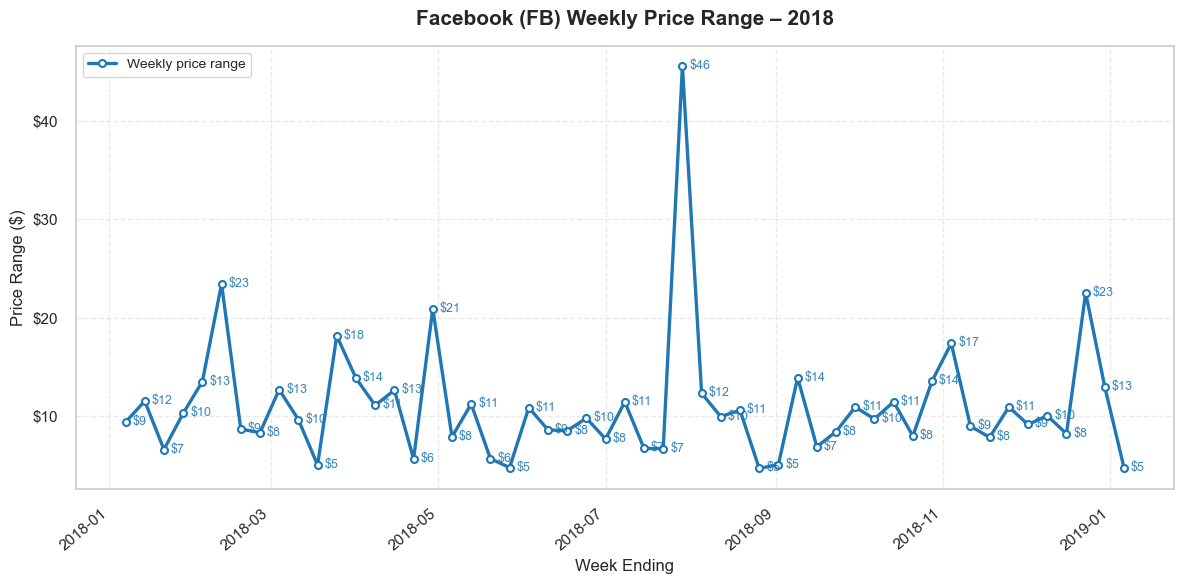

Weekly price range summary:
count    53.00
mean     11.01
std       6.41
min       4.64
25%       7.85
50%       9.76
75%      12.29
max      45.62
Name: price_range, dtype: float64


In [12]:
# 1. Ensure the date column is the DatetimeIndex and sorted
if not isinstance(fb.index, pd.DatetimeIndex):
    fb = fb.set_index('date').sort_index()

# 2. Resample the data to weekly frequency
weekly = fb.resample('W')

# 3. Compute the weekly maximum high price and weekly minimum low price
weekly_agg = weekly.agg({
    'high': 'max',
    'low': 'min'
})

# 4. Calculate the weekly price range
weekly_agg['price_range'] = weekly_agg['high'] - weekly_agg['low']

# 5. Create a line plot of the weekly price range with labels and formatting
plt.figure(figsize=(12, 6))

plt.plot(
    weekly_agg.index,
    weekly_agg['price_range'],
    color='#1f77b4',
    linewidth=2.4,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    markeredgecolor='#1f77b4',
    label='Weekly price range'
)

ax = plt.gca()

# Add value labels to the right of each data point
for x, y in zip(weekly_agg.index, weekly_agg['price_range']):
    ax.annotate(
        f'${y:,.0f}',
        xy=(x, y),
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9,
        va='center',
        ha='left',
        color='#1f77b4',
        alpha=0.9
    )

plt.title(
    'Facebook (FB) Weekly Price Range – 2018',
    fontsize=15,
    fontweight='bold',
    pad=15
)
plt.xlabel('Week Ending', fontsize=12)
plt.ylabel('Price Range ($)', fontsize=12)

plt.grid(True, alpha=0.4, linestyle='--')
plt.xticks(rotation=40, ha='right')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

# 6. Display summary statistics for the weekly price range
print('Weekly price range summary:')
print(weekly_agg['price_range'].describe().round(2))

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

This exercise analyzed how Facebook’s weekly trading range changed over time by computing the difference between the weekly maximum high price and the weekly minimum low price. After ensuring the dataset used a proper DatetimeIndex, the data was resampled to weekly frequency and the weekly high and low values were aggregated. The resulting price range (`max_high – min_low`) provided a clear measure of weekly volatility.

A line plot was then created to visualize these weekly ranges, with each point labeled to show the exact dollar value. This made it easy to identify weeks with unusually large or small trading ranges. The final visualization highlighted how Facebook’s price fluctuations varied throughout the year, and the summary statistics offered additional context about the overall distribution of weekly ranges.

## **Chapter 6 — Exercise 1**  
### **Correlation Between Magnitude and Tsunami Occurrence (mb Type Only)**

**Task:**  
Using Seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami for earthquakes measured with the `mb` magnitude type.

**Steps to complete:**

1. Filter the dataset to include only earthquakes where `magType == 'mb'`.  
2. Compute the correlation matrix.  
3. Create a Seaborn heatmap to visualize the correlation coefficients.  
4. Add a title and axis formatting for readability.  
5. Print the numeric correlation value for reference.

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

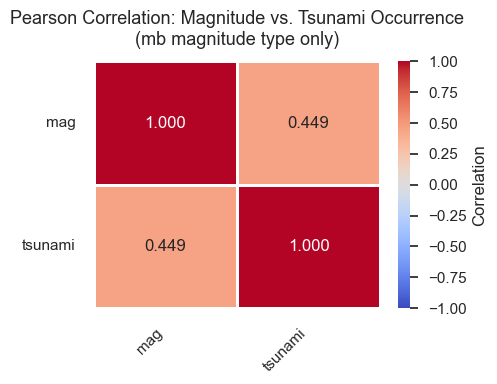

Correlation between magnitude and tsunami (mb quakes): 0.449


In [13]:
# 1. Filter to mb magnitude type and keep only the two relevant columns
mb_quakes = earthquakes[earthquakes['magType']
                        == 'mb'][['mag', 'tsunami']].dropna()

# 2. Compute the correlation matrix
corr_matrix = mb_quakes.corr()

# 3. Create a Seaborn heatmap to visualize the correlation coefficients
plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.8,
    cbar_kws={'label': 'Correlation'},
    annot_kws={'size': 12}
)

# 4. Add title and axis formatting
plt.title(
    'Pearson Correlation: Magnitude vs. Tsunami Occurrence\n(mb magnitude type only)',
    fontsize=13,
    pad=12
)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 5. Print the numeric correlation value
print(
    f"Correlation between magnitude and tsunami (mb quakes): {corr_matrix.loc['mag', 'tsunami']:.3f}")

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

This exercise examined the relationship between earthquake magnitude and tsunami occurrence for events measured using the **mb** magnitude type. After filtering the dataset to include only mb earthquakes, the analysis focused on the two relevant variables: `mag` and `tsunami`. A correlation matrix was computed and visualized using a Seaborn heatmap.

The resulting correlation coefficient was approximately **0.449**, indicating a **moderate positive relationship** between magnitude and tsunami occurrence within this subset of earthquakes. This suggests that, for mb‑measured events, higher magnitudes were somewhat more likely to be associated with tsunamis, although the relationship was not strong enough to be considered highly predictive. The printed numeric value provided a clear reference point to support this interpretation.

## **Chapter 6 — Exercise 2**  
### **Boxplots of Facebook Volume and Closing Prices with Tukey Fences**

**Task:**  
Create boxplots of Facebook’s traded volume and closing prices, and draw reference lines for the Tukey fence bounds using a multiplier of 1.5. The bounds are defined as  
\[
Q1 - 1.5 \times IQR \quad \text{and} \quad Q3 + 1.5 \times IQR.
\]  
Use the `quantile()` method to compute these values and display the two boxplots using subplots.

**Steps to complete:**

1. Select the `volume` and `close` columns and drop missing values.  
2. Compute Q1, Q3, IQR, and the Tukey fence bounds for each variable using `quantile()`.  
3. Create two subplots for the boxplots (one for volume, one for closing price).  
4. Draw horizontal reference lines for the lower and upper Tukey fences on each subplot.  
5. Add titles, axis labels, and legends for clarity.  
6. Format the layout for readability.

<hr style='height:2px; background-color:black; border:none; margin:25px 0;'>

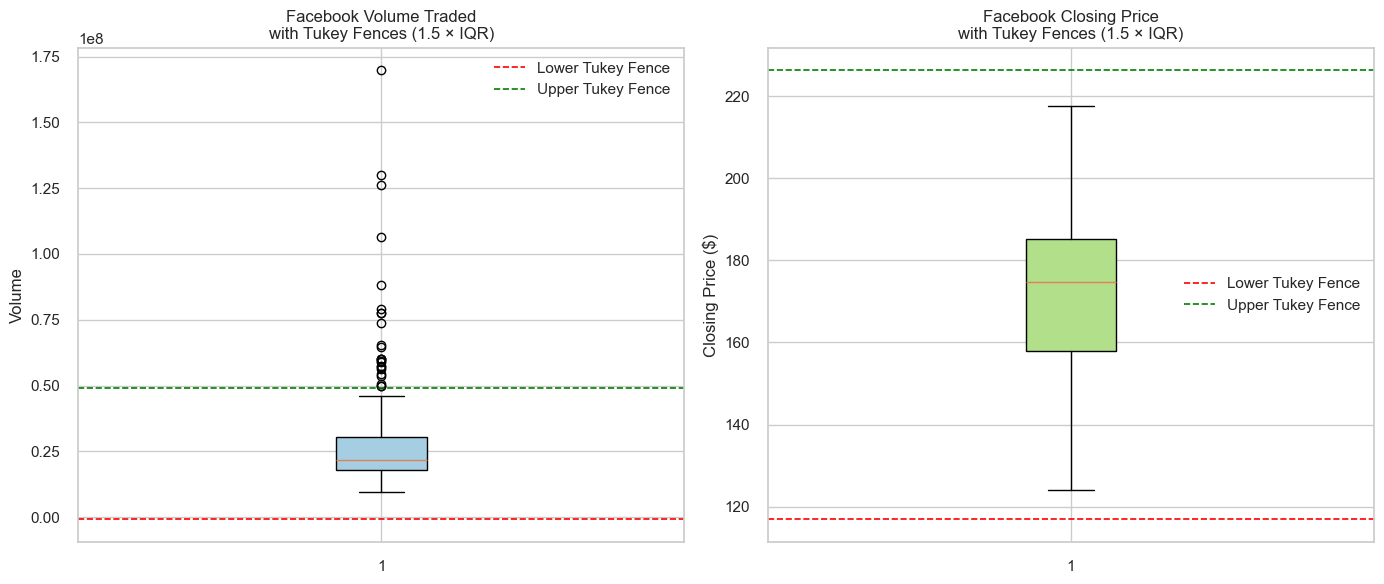

In [14]:
# 1. Select the two variables for analysis
fb_data = fb[['volume', 'close']].dropna()

# 2. Compute Q1, Q3, IQR, and Tukey fence bounds for each variable


def tukey_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper


vol_q1, vol_q3, vol_iqr, vol_lower, vol_upper = tukey_bounds(fb_data['volume'])
close_q1, close_q3, close_iqr, close_lower, close_upper = tukey_bounds(
    fb_data['close'])

# 3. Create subplots for the boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 4. Draw the volume boxplot and Tukey fences
axes[0].boxplot(
    fb_data['volume'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#a6cee3')
)
axes[0].axhline(
    vol_lower,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label='Lower Tukey Fence'
)
axes[0].axhline(
    vol_upper,
    color='green',
    linestyle='--',
    linewidth=1.2,
    label='Upper Tukey Fence'
)

axes[0].set_title(
    'Facebook Volume Traded\nwith Tukey Fences (1.5 × IQR)',
    fontsize=12
)
axes[0].set_ylabel('Volume')
axes[0].legend()

# 5. Draw the closing price boxplot and Tukey fences
axes[1].boxplot(
    fb_data['close'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#b2df8a')
)
axes[1].axhline(
    close_lower,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label='Lower Tukey Fence'
)
axes[1].axhline(
    close_upper,
    color='green',
    linestyle='--',
    linewidth=1.2,
    label='Upper Tukey Fence'
)

axes[1].set_title(
    'Facebook Closing Price\nwith Tukey Fences (1.5 × IQR)',
    fontsize=12
)
axes[1].set_ylabel('Closing Price ($)')
axes[1].legend()

# 6. Format layout for readability
plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

### **Summary**

This exercise explored the distribution of Facebook’s traded volume and closing prices using boxplots, with additional emphasis on identifying potential outliers through Tukey fences. After selecting the relevant variables and removing missing values, the first and third quartiles were computed using the `quantile()` method. These values were used to calculate the interquartile range (IQR) and determine the lower and upper Tukey fence bounds. The Tukey fence bounds were computed as:

$$Q1 - 1.5 \times IQR \quad \text{and} \quad Q3 + 1.5 \times IQR.$$.

Two subplots were created to display the boxplots side by side—one for volume and one for closing prices. Horizontal reference lines were added to each subplot to mark the Tukey fence boundaries. The resulting visualizations showed that trading volume exhibited a wider spread and more extreme values relative to its fence limits, suggesting the presence of potential outliers. In contrast, closing prices were more tightly clustered, with fewer values extending beyond the Tukey bounds. Together, these plots provided a clear comparison of variability and potential outlier behavior between the two financial metrics.


<div style="border: 2px solid black; padding: 10px;">

## **Reflection - Week 7 & 8**

### **Overall Assessment**
This assignment provided a comprehensive opportunity to apply a wide range of data analysis and visualization techniques across multiple datasets. Each exercise built on core skills such as filtering, grouping, resampling, computing statistical measures, and creating clear visual representations. The combination of financial data, seismic data, and geospatial mapping made the work both technically engaging and conceptually diverse. Overall, the assignment strengthened my ability to structure analyses, interpret results, and present findings in a clean, organized, and reproducible format.

### **Easier Portions**
Some parts of the assignment were more straightforward and flowed naturally due to familiarity with the underlying methods:
- Resampling and aggregating the Facebook stock data to compute weekly price ranges.
- Creating correlation heatmaps using Seaborn once the data was filtered to the correct subset.
- Generating boxplots and computing Tukey fences using quantile-based calculations.

These tasks relied on well‑practiced pandas operations and standard visualization patterns, making them easier to implement.

### **More Challenging Portions**
Other components required more careful attention, either due to complexity or the need for precise formatting:
- Constructing the Cartopy tectonic map and ensuring all symbols, labels, and legend elements matched correctly.
- Managing subplot formatting and axis alignment to keep visualizations clean and readable.
- Interpreting correlation values accurately and ensuring the written summaries reflected correct statistical meaning.

These challenges ultimately improved my attention to detail and reinforced the importance of clarity in both code and interpretation.

---

## **Start / Stop / Continue**

### **Start**
- Starting each exercise by outlining the steps in markdown before writing any code.
- Using more annotation and labeling in visualizations to make insights clearer at a glance.
- Incorporating more interpretive commentary in summaries to connect results back to the underlying concepts.

### **Stop**
- Spending too much time over‑refining plot aesthetics before confirming the core logic is correct.
- Allowing minor formatting inconsistencies to slip into early drafts of markdown cells.
- Relying on memory for statistical interpretation instead of verifying definitions and ranges.

### **Continue**
- Maintaining a clean, consistent structure across all exercises with aligned steps, code, and summaries.
- Using helper functions (like the Tukey fence calculator) to keep code modular and readable.
- Applying reproducible workflows that include sorting, indexing, and validating data before analysis.
